## Imports

In [151]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import ANFIS, Hybrid_learning_algorithm, Basic_optimizer_training_algorithm, EarlyStopping, get_measures, Gaussian_MF

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)
from sklearn.model_selection import train_test_split

In [154]:
from ucimlrepo import fetch_ucirepo

## Data

In [155]:
auto_mpg = fetch_ucirepo(id=9)

X = auto_mpg.data.features 
y = auto_mpg.data.targets

In [156]:
X = X.fillna(X.mean()).astype(np.float32)
y = y.astype(np.float32)

In [157]:
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8.0,130.0,3504.0,12.0,70.0,1.0
1,350.0,8.0,165.0,3693.0,11.5,70.0,1.0
2,318.0,8.0,150.0,3436.0,11.0,70.0,1.0
3,304.0,8.0,150.0,3433.0,12.0,70.0,1.0
4,302.0,8.0,140.0,3449.0,10.5,70.0,1.0
...,...,...,...,...,...,...,...
393,140.0,4.0,86.0,2790.0,15.6,82.0,1.0
394,97.0,4.0,52.0,2130.0,24.6,82.0,2.0
395,135.0,4.0,84.0,2295.0,11.6,82.0,1.0
396,120.0,4.0,79.0,2625.0,18.6,82.0,1.0


In [158]:
#sns.pairplot(X)
#plt.show()

In [159]:
#for column in X.columns:
#    plt.figure(figsize=(6, 4))
#    sns.scatterplot(x=X[column], y=y.squeeze(), alpha=0.7)
#    plt.xlabel(column)
#    plt.ylabel('Target')
#    plt.title(f'{column} vs Target')
#    plt.grid(True)
#    plt.show()

In [160]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float32
 1   cylinders     398 non-null    float32
 2   horsepower    398 non-null    float32
 3   weight        398 non-null    float32
 4   acceleration  398 non-null    float32
 5   model_year    398 non-null    float32
 6   origin        398 non-null    float32
dtypes: float32(7)
memory usage: 11.0 KB


In [161]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [162]:
scaler = MinMaxScaler(feature_range=(-1, 1))
#scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [163]:
#scaled_df = pd.DataFrame(x_train, columns=X.columns)
#sns.pairplot(scaled_df)
#plt.show()

In [164]:
#for column in scaled_df.columns:
#    plt.figure(figsize=(6, 4))
#    sns.scatterplot(x=scaled_df[column], y=y_train.squeeze(), alpha=0.7)
#    plt.xlabel(column)
#    plt.ylabel('Target')
#    plt.title(f'{column} vs Target')
#    plt.grid(True)
#    plt.show()

In [165]:
x_train.shape, x_test.shape

((199, 7), (199, 7))

In [166]:
x_train = torch.from_numpy(x_train)
x_test = torch.from_numpy(x_test)
y_train = torch.from_numpy(y_train.values).squeeze()
y_test = torch.from_numpy(y_test.values).squeeze()

In [167]:
x_train.dtype, y_train.dtype

(torch.float32, torch.float32)

In [168]:
loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size = 4, shuffle = True)
x_trainset = loader.dataset.tensors[0]
y_trainset = loader.dataset.tensors[1]

## Model & Training

In [169]:
#mf_distribution = [4, 4, 2, 4, 4, 3, 4]
mf_distribution = [3, 3, 2, 3, 3, 2, 3]
#mf_distribution = [2, 2, 2, 2, 2, 2, 2]

In [170]:
model = ANFIS(
    mf_distribution=mf_distribution,
    membership_function=Gaussian_MF
)

In [171]:
model.init_premises(x_train)

In [172]:
model.init_consequents(x_train, y_train)

In [ ]:
loss_fn = nn.functional.mse_loss

early_stopping = EarlyStopping(patience=30, delta=0.01)

In [174]:
#optimizer = torch.optim.AdamW
#params = {'lr': 0.001, 'weight_decay': 0.01}
#
#trainer = Hybrid_learning_algorithm(
#    epochs=1000,
#    loss_function=loss_fn,
#    optimizer=optimizer,
#    optimizer_params=params,
#    validation=0.3,
#    early_stopping=early_stopping
#)

In [175]:
optimizer = torch.optim.AdamW
params = {'lr': 0.001, 'weight_decay': 0.01}

trainer = Basic_optimizer_training_algorithm(
    epochs=1000,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [176]:
trainer(model, loader, verbose=True)

Epoch:    1/1000 - loss: 67.743248 - validation loss: 66.998421
Epoch:    2/1000 - loss: 62.356155 - validation loss: 62.827358
Epoch:    3/1000 - loss: 57.635918 - validation loss: 58.013554
Epoch:    4/1000 - loss: 52.742443 - validation loss: 53.678833
Epoch:    5/1000 - loss: 48.255219 - validation loss: 49.103981
Epoch:    6/1000 - loss: 43.877953 - validation loss: 45.041439
Epoch:    7/1000 - loss: 39.654701 - validation loss: 41.085270
Epoch:    8/1000 - loss: 36.267418 - validation loss: 37.637558
Epoch:    9/1000 - loss: 33.283020 - validation loss: 34.552692
Epoch:   10/1000 - loss: 30.934834 - validation loss: 32.671185
Epoch:   11/1000 - loss: 28.844454 - validation loss: 30.380411
Epoch:   12/1000 - loss: 27.087255 - validation loss: 28.484112
Epoch:   13/1000 - loss: 25.708935 - validation loss: 27.067980
Epoch:   14/1000 - loss: 24.525234 - validation loss: 25.636358
Epoch:   15/1000 - loss: 23.505095 - validation loss: 24.460653
Epoch:   16/1000 - loss: 22.542044 - val

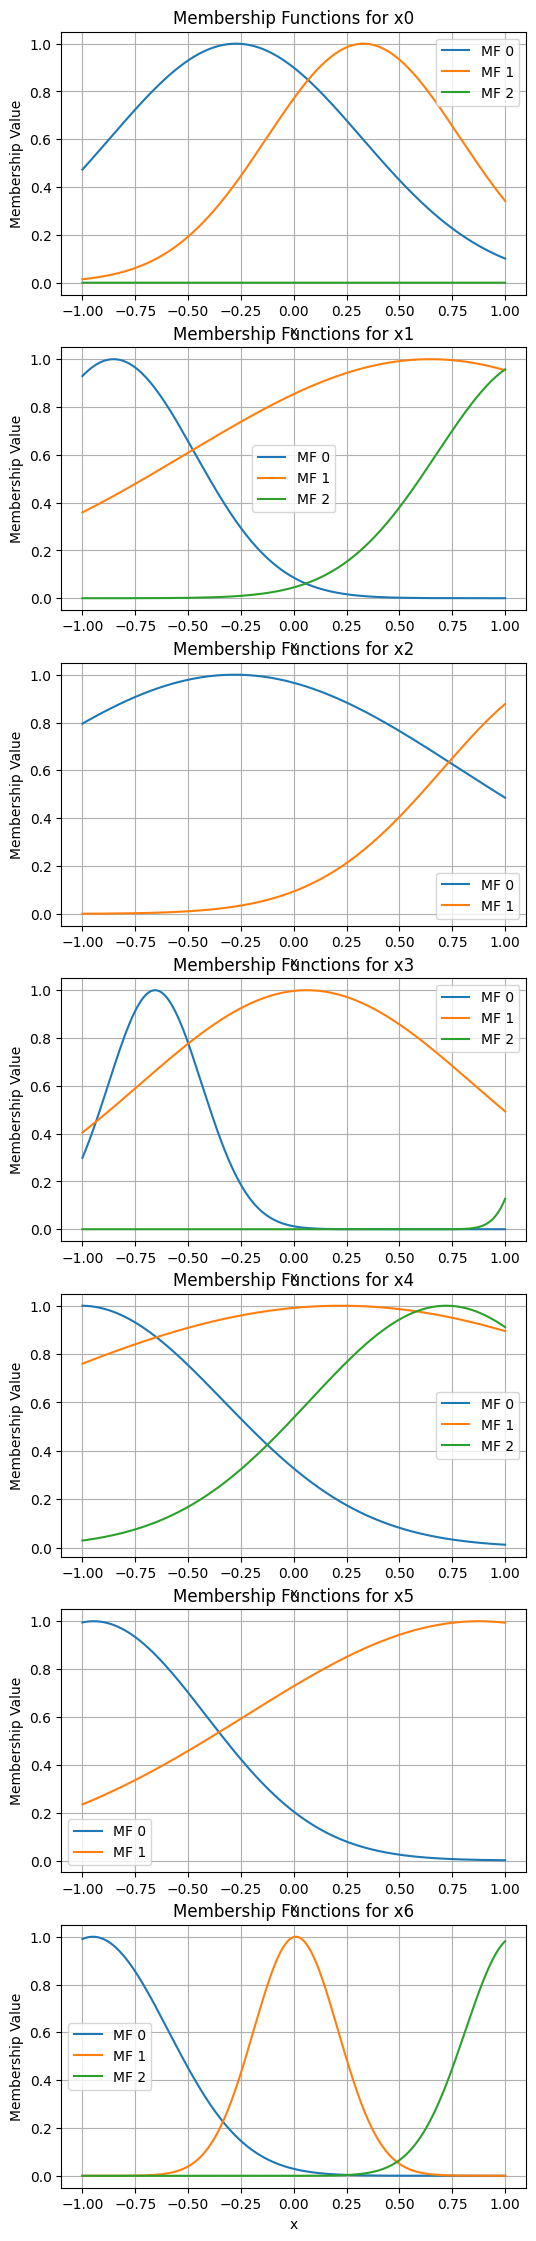

In [177]:
model.plot_premises(group_by_dim=True)

In [178]:
model.premises_structure

,mu (x0),sigma (x0),mu (x1),sigma (x1),mu (x2),sigma (x2),mu (x3),sigma (x3),mu (x4),sigma (x4),mu (x5),sigma (x5),mu (x6),sigma (x6)
MF 0,-0.273133,0.594216,-0.852703,0.384941,-0.279728,1.064246,-0.656019,0.221265,-1.004885,0.672273,-0.946648,0.531120,-0.950158,0.356791
MF 1,0.330020,0.457257,0.646037,1.149686,1.306862,0.600684,0.061469,0.789040,0.222319,1.650620,0.876095,1.101403,0.009994,0.200226
MF 2,1.240901,0.047719,1.133971,0.455802,NaN,NaN,1.247230,0.121796,0.721330,0.646899,NaN,NaN,1.045440,0.233576


In [179]:
test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 6.636645317077637
RMSE: 2.5761687755584717
MAE: 1.908185601234436
R2: 0.8885661959648132
MAPE: 0.08269008249044418


In [180]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 6.514995574951172
RMSE: 2.5524489879608154
MAE: 1.8169147968292236
R2: 0.8954346776008606
MAPE: 0.07663841545581818


## Results

train_test_split=0.5  
scaler=MinMaxScaler  
mf_distribution = [3, 3, 2, 3, 3, 2, 3]  
membership_function=Gaussian_MF  
init_premises  
loss_fn = nn.functional.mse_loss  
early_stopping = EarlyStopping(patience=20, delta=0.01)  
optimizer = torch.optim.AdamW   
validation=0.3  

R2 = 0.74
- params = {'lr': 0.008, 'weight_decay': 0.01, 'eps':1e-2}
- scaler =  MinMaxScaler  

R2 = 0.77
- params = {'lr': 0.008, 'weight_decay': 0.01, 'eps':1e-2}
- scaler =  StandardScaler  

R2 = 0.80
- params = {'lr': 0.006, 'weight_decay': 0.01, 'eps':1e-2}
- scaler =  MinMaxScaler  

R2 = 0.72
- params = {'lr': 0.006, 'weight_decay': 0.01, 'eps':1e-2}
- scaler =  StandardScaler  